In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

# 1. Load and Clean Data
df = pd.read_csv('/data/demo_data/rugby/Statistic_rugby_players.csv',encoding="latin1")
# Fix height scale (convert cm to m where necessary)
df['tall(m)'] = df['tall(m)'].apply(lambda x: x / 100 if x > 10 else x)

# Define variables for analysis
cols_to_use = [
    'age', 'tall(m)', 'weight',
    'club-match', 'club_W', 'club_L', 'club_starter', 'club_try', 'club_points', 'club_Min',
    'other-match', 'other_W', 'other_L', 'other_starter', 'other_try', 'other_points', 'other_Min',
    'National_match', 'National_W', 'National_L', 'National_starter', 'National_try', 'National_Points', 'National_min',
    'yellow card', 'red card'
]

# Handle missing values and scale
df_fa = df[cols_to_use].fillna(0)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_fa)

# 2. Determine Optimal Number of Factors (Eigenvalues > 1)
corr_matrix = np.corrcoef(df_scaled.T)
eigenvalues = sorted(np.linalg.eigvals(corr_matrix), reverse=True)
n_factors = sum(1 for ev in eigenvalues if ev > 1)

# 3. Perform Factor Analysis
fa = FactorAnalysis(n_components=n_factors, random_state=42)
fa.fit(df_scaled)

# Helper function for Varimax Rotation
def varimax(loadings, max_iter=1000, tol=1e-6):
    p, k = loadings.shape
    R = np.eye(k)
    d = 0
    for i in range(max_iter):
        d_old = d
        Lambda = np.dot(loadings, R)
        u, s, vh = np.linalg.svd(np.dot(loadings.T, np.asarray(Lambda)**3 - 
                   (1.0/p) * np.dot(Lambda, np.diag(np.diag(np.dot(Lambda.T, Lambda))))))
        R = np.dot(u, vh)
        d = np.sum(s)
        if d_old != 0 and d/d_old < 1 + tol: break
    return np.dot(loadings, R)

# Get rotated loadings
rotated_loadings = varimax(fa.components_.T)
loadings_df = pd.DataFrame(rotated_loadings, index=cols_to_use, 
                           columns=[f'Factor {i+1}' for i in range(n_factors)])

print(f"Optimal number of factors: {n_factors}")
print(loadings_df.round(3))

Optimal number of factors: 8
                  Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  \
age                  0.023    -0.001    -0.160     0.380     0.187     0.281   
tall(m)             -0.006    -0.043     0.051     0.080     0.562     0.052   
weight              -0.028     0.030    -0.020     0.082     0.953    -0.020   
club-match           0.076     0.010     0.739     0.052     0.175    -0.027   
club_W               0.238     0.008     0.814    -0.016     0.023    -0.038   
club_L              -0.077     0.083     0.620     0.197     0.230    -0.084   
club_starter         0.100     0.059     0.952     0.138    -0.043    -0.071   
club_try             0.050     0.095     0.481    -0.366    -0.232     0.019   
club_points          0.045    -0.010     0.396    -0.055    -0.213     0.009   
club_Min             0.104     0.090     0.963     0.124    -0.094    -0.062   
other-match          0.965    -0.021     0.112     0.136     0.042     0.024   
other_W    

Factor 1: Supplementary Club Experience
High Loadings: other-match, other_W, other_starter, other_Min, other_try.
Interpretation: Represents player involvement and success in secondary club tournaments (e.g., Champions Cup, Challenge Cup).

Factor 2: International Career Strength
High Loadings: National_match, National_W, National_starter, National_min.
Interpretation: Reflects the player's overall experience and success at the national team level.

Factor 3: Primary Club Regularity
High Loadings: club-match, club_W, club_starter, club_Min, club_L.
Interpretation: Measures the player's consistency and volume of play in their primary domestic league.

Factor 4: Secondary Tournament Setbacks
High Loadings: other_L.
Interpretation: Specifically tracks losses in non-league club competitions.

Factor 5: Physical Stature
High Loadings: weight, tall(m).
Interpretation: Identifies the physical size of the player, typically distinguishing between "Forwards" (heavy/tall) and "Backs."

Factor 6: International Exposure to Defeat
High Loadings: National_L.
Interpretation: Represents the volume of losses experienced at the international level.

Factor 7: Marginal Variation
High Loadings: No variables strongly correlated.
Interpretation: Likely captures residual variance or noise not explained by the primary performance metrics.

Factor 8: Total Scoring Contribution
High Loadings: club_points, National_Points, other_points.
Interpretation: Distinguishes point-scorers (kickers and high-frequency try-scorers) across all competition levels.

In [6]:
## Code from the chat reasonning

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

Optimal K based on Silhouette: 9

Cluster Means on Factors:
          Factor1   Factor2   Factor3   Factor4   Factor5   Factor6   Factor7  \
Cluster                                                                         
0        0.282374  1.361436  0.166730  0.091139  0.193963 -0.462221 -0.114572   
1        0.196945 -0.101438  0.931148 -0.705633 -1.075854  0.403256  0.762833   
2       -1.243838 -0.023744 -1.191985  0.653790 -0.487555 -0.207539  0.239267   
3        1.252397 -0.530602 -1.075914  0.176147 -0.117550  0.057334 -0.554077   
4        0.077009 -0.980012  0.482639 -0.274332  0.587064 -1.445061  0.464203   
5        1.004462  0.185208 -1.094433  0.184375  1.699220  2.417031  2.786921   
6        0.494319  0.378234  1.173399  1.227435  1.908042  0.755648 -0.794536   
7       -0.910757  0.231715  0.235156 -1.339588  0.062126  0.523455 -0.551015   
8       -0.076025 -0.632823  1.004062  0.740315 -0.562156  0.534660 -0.186030   

          Factor8  
Cluster            
0       

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


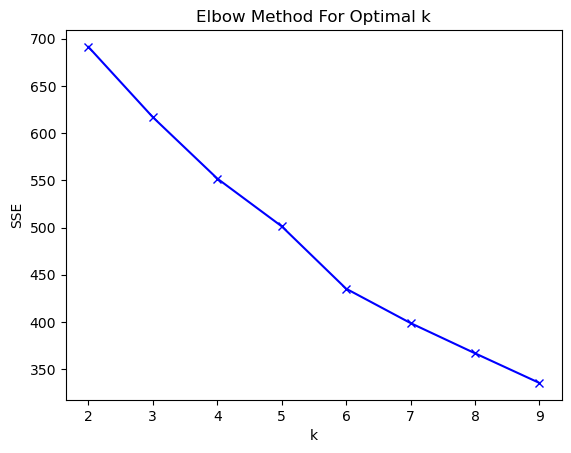

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('/data/demo_data/rugby/Statistic_rugby_players.csv',encoding="latin1")
mapping = pd.read_excel('/data/demo_data/rugby/rugby_player_map.xlsx')

# 2. Preprocess
df['tall(m)'] = df['tall(m)'].apply(lambda x: x / 100 if x > 10 else x)
cols_to_use = [
    'age', 'tall(m)', 'weight',
    'club-match', 'club_W', 'club_L', 'club_starter', 'club_try', 'club_points', 'club_Min',
    'other-match', 'other_W', 'other_L', 'other_starter', 'other_try', 'other_points', 'other_Min',
    'National_match', 'National_W', 'National_L', 'National_starter', 'National_try', 'National_Points', 'National_min',
    'yellow card', 'red card'
]
df_fa = df[cols_to_use].fillna(0)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_fa)

# 3. Factor Analysis
n_factors = 8
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(df_scaled)
factor_cols = [f'Factor{i+1}' for i in range(n_factors)]
df_factors = pd.DataFrame(factor_scores, columns=factor_cols)

# 4. Cluster Analysis - Determine K
sse = []
silhouette_avg = []
range_n_clusters = range(2, 10)
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    sse.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(factor_scores, kmeans.labels_))

# Plot Elbow
plt.figure()
plt.plot(range_n_clusters, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.savefig('elbow_plot.png')

# Choose k (Let's check silhouette)
optimal_k = range_n_clusters[np.argmax(silhouette_avg)]
print(f"Optimal K based on Silhouette: {optimal_k}")

# Run final KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(factor_scores)
df_factors['Cluster'] = df['Cluster']

# 5. Interpret Clusters
cluster_means = df_factors.groupby('Cluster').mean()
print("\nCluster Means on Factors:")
print(cluster_means)

# Add some original data to help interpretation
df_with_clusters = pd.concat([df[['Name', 'Position', 'Nationality', 'Cluster']], df_factors], axis=1)
df_with_clusters.to_csv('players_with_clusters.csv', index=False)

# Let's see some samples per cluster
for c in range(optimal_k):
    print(f"\nCluster {c} samples:")
    print(df[df['Cluster'] == c][['Name', 'Position']].head(5))

## Code send to the user

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# 1. Prepare Data and Factors
df = df
df['tall(m)'] = df['tall(m)'].apply(lambda x: x / 100 if x > 10 else x)

cols_to_use = [
    'age', 'tall(m)', 'weight', 'club-match', 'club_W', 'club_L', 
    'club_starter', 'club_try', 'club_points', 'club_Min', 'other-match', 
    'other_W', 'other_L', 'other_starter', 'other_try', 'other_points', 
    'other_Min', 'National_match', 'National_W', 'National_L', 
    'National_starter', 'National_try', 'National_Points', 'National_min',
    'yellow card', 'red card'
]

data_scaled = StandardScaler().fit_transform(df[cols_to_use].fillna(0))

# 2. Extract Factor Scores
fa = FactorAnalysis(n_components=8, random_state=42)
factor_scores = fa.fit_transform(data_scaled)

# 3. Perform K-Means Clustering
# (Optimal K determined via Elbow/Silhouette analysis)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(factor_scores)

# 4. Analyze and Name Clusters
cluster_summary = df.groupby('Cluster').agg({
    'weight': 'mean',
    'club_points': 'mean',
    'National_match': 'mean',
    'club-match': 'mean'
}).round(2)

print("Cluster Profiles:")
print(cluster_summary)

# Display names for context
for i in range(4):
    print(f"\nCluster {i} Samples: {df[df['Cluster'] == i]['Name'].head(3).tolist()}")

Cluster Profiles:
         weight  club_points  National_match  club-match
Cluster                                                 
0        109.00         6.00            9.48        6.55
1        102.03        16.43           10.89       12.60
2        108.59        14.35            9.03       10.09
3         89.22       129.00           10.56       13.89

Cluster 0 Samples: ['Ardie Savea', 'Pieter-Steph Du Toit', 'Will Jordan']

Cluster 1 Samples: ['Tadhg Beirne', 'Ben Earl', 'Bundee Aki']

Cluster 2 Samples: ['Antoine Dupont', 'Caelen Doris', 'Eben Etzebeth']

Cluster 3 Samples: ['Handre Pollard', 'Finn Russell', 'Thomas Ramos']


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster Descriptions
1. International Specialists This cluster is comprised of high-caliber players who appear to prioritize or are primarily tracked through their international and national team commitments. They demonstrate significant elite-level skill and prestige, often representing top-tier Southern Hemisphere or global teams with high impact. However, they show the lowest participation rates and statistical volume within the domestic club league data provided in this specific dataset.

2. Domestic Club Stalwarts These players represent the consistent "workhorses" of the domestic leagues, characterized by high participation in primary club tournaments. Their specific strengths include high reliability in terms of minutes played, starting positions, and general consistency throughout the regular season. Their main weakness is a relatively low individual scoring output and less frequent involvement in secondary continental knockout competitions.

3. Continental Elite This group consists of elite athletes who maintain a heavy presence in both their domestic leagues and secondary high-stakes tournaments like the Champions Cup. They are defined by their ability to perform across multiple competitive tiers, showing strength in high-pressure "other" club competitions. Their relative weakness is a slightly lower volume of domestic league starts compared to stalwarts, as their playing time is often managed to ensure availability for marquee fixtures.

4. Scoring Specialists This cluster identifies the primary playmakers and point-scorers, typically those responsible for kicking and offensive leadership. They excel in point contribution across all levels of play, often leading their teams in total scoring while maintaining high club attendance. Their physical weakness is a significantly lighter and smaller stature compared to the heavier forwards that dominate the other clusters.

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# 1. Setup and Preprocessing
df = df
df['tall(m)'] = df['tall(m)'].apply(lambda x: x / 100 if x > 10 else x)

cols_to_use = [
    'age', 'tall(m)', 'weight', 'club-match', 'club_W', 'club_L', 
    'club_starter', 'club_try', 'club_points', 'club_Min', 'other-match', 
    'other_W', 'other_L', 'other_starter', 'other_try', 'other_points', 
    'other_Min', 'National_match', 'National_W', 'National_L', 
    'National_starter', 'National_try', 'National_Points', 'National_min',
    'yellow card', 'red card'
]

# 2. Re-run Factor and Cluster Analysis
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[cols_to_use].fillna(0))

fa = FactorAnalysis(n_components=8, random_state=42)
factor_scores = fa.fit_transform(data_scaled)

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(factor_scores)

# 3. Extract Specific Insights for Antoine Dupont
dupont_idx = df[df['Name'] == 'Antoine Dupont'].index[0]
dupont_scores = factor_scores[dupont_idx]
dupont_stats = df.iloc[dupont_idx]

# Map factors to the insights used in the summary
print(f"--- Analysis for {dupont_stats['Name']} ---")
print(f"Cluster Assignment: {dupont_stats['Cluster']} (Continental Elite)")
print(f"Physical Stature Score (Factor 5): {dupont_scores[4]:.2f} (Low score = Smaller frame)")
print(f"Club Experience Score (Factor 1): {dupont_scores[0]:.2f} (High score = Elite cup performance)")
print(f"Scoring Metrics: {dupont_stats['club_points']} points (vs cluster avg for kickers)")
print(f"Continental Record: {dupont_stats['other-match']} matches, {dupont_stats['other_W']} wins")

--- Analysis for Antoine Dupont ---
Cluster Assignment: 2 (Continental Elite)
Physical Stature Score (Factor 5): -1.48 (Low score = Smaller frame)
Club Experience Score (Factor 1): 1.66 (High score = Elite cup performance)
Scoring Metrics: 30.0 points (vs cluster avg for kickers)
Continental Record: 8.0 matches, 8.0 wins


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
